In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import numpy as np
import seaborn as sns


In [20]:
df=pd.read_csv("churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [21]:
df.drop("customerID",axis=1,inplace=True)
df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [23]:
cat_cols=df.select_dtypes(include="object").columns
for col in cat_cols :
    print(col)
    print("\n")
    print((list(df[col].unique())))
    print('\n')

gender


['Female', 'Male']


Partner


['Yes', 'No']


Dependents


['No', 'Yes']


PhoneService


['No', 'Yes']


MultipleLines


['No phone service', 'No', 'Yes']


InternetService


['DSL', 'Fiber optic', 'No']


OnlineSecurity


['No', 'Yes', 'No internet service']


OnlineBackup


['Yes', 'No', 'No internet service']


DeviceProtection


['No', 'Yes', 'No internet service']


TechSupport


['No', 'Yes', 'No internet service']


StreamingTV


['No', 'Yes', 'No internet service']


StreamingMovies


['No', 'Yes', 'No internet service']


Contract


['Month-to-month', 'One year', 'Two year']


PaperlessBilling


['Yes', 'No']


PaymentMethod


['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']


TotalCharges


['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5', '1949.4', '301.9', '3046.05', '3487.95', '587.45', '326.8', '5681.1', '5036.3', '2686.05', '7895.15', '1022.95', '7382.25', '528.35', '1862.9', '39.65', '202.25', '20.15', '35

C:\Users\Access\AppData\Local\Temp\ipykernel_7120\1332327526.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=df.select_dtypes(include="object").columns


In [24]:
df["TotalCharges"].unique()

<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',
 ...
 '2625.25', '6886.25',  '1495.1',   '743.3',  '1419.4',  '1990.5',  '7362.9',
  '346.45',   '306.6',  '6844.5']
Length: 6531, dtype: str

In [25]:
# df["TotalCharges"]=df["TotalCharges"].map({" ":np.nan})


In [8]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

In [9]:
df[df["TotalCharges"].isna()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [10]:
df.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [13]:
data=df.copy()

In [14]:
data.shape

(7043, 20)

In [15]:
data.isna().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import RobustScaler,OrdinalEncoder
from sklearn.model_selection import train_test_split

In [27]:
x=data.drop("Churn",axis=1)
y=data["Churn"]

In [28]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=22)

In [11]:
df["TotalCharges"]=df["TotalCharges"].fillna(df["TotalCharges"].mean())

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [13]:
np.max(df["tenure"])

np.int64(72)

([<matplotlib.axis.XTick at 0x160beff9550>,
 [Text(0, 0, '0'),
  Text(6, 0, '6'),
  Text(12, 0, '12'),
  Text(18, 0, '18'),
  Text(24, 0, '24'),
  Text(30, 0, '30'),
  Text(36, 0, '36'),
  Text(42, 0, '42'),
  Text(48, 0, '48'),
  Text(54, 0, '54'),
  Text(60, 0, '60'),
  Text(66, 0, '66'),
  Text(72, 0, '72')])

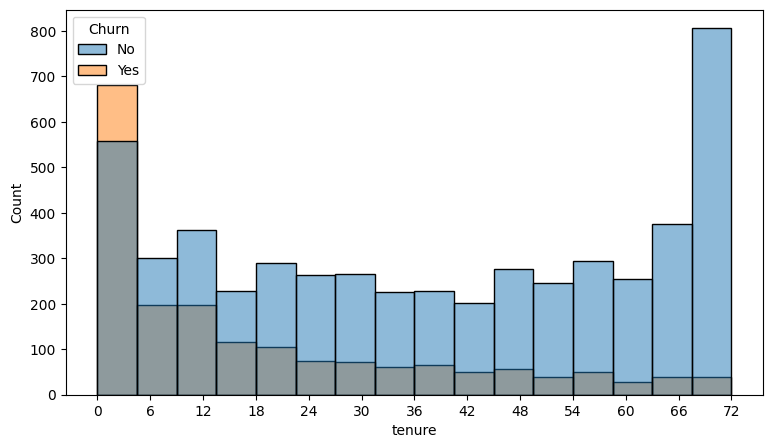

In [14]:
plt.figure(figsize=(9,5))
sns.histplot(data=df,x="tenure",hue="Churn")
plt.xticks(np.arange(0,73,6))

In [15]:
df[["StreamingMovies","MultipleLines","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV"]]=df[["StreamingMovies","MultipleLines","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV"]].replace({"No internet service":"No","No phone service":"No"})

In [16]:
object_cols=df.select_dtypes(include="object").columns
for c in object_cols:
    print(c)
    print(df[c].unique())
    print("\n\n\n\n\n\n --------------- \n\n\n\n\n\n\n")

gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str






 --------------- 







Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str






 --------------- 







Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str






 --------------- 







PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str






 --------------- 







MultipleLines
<StringArray>
['No', 'Yes']
Length: 2, dtype: str






 --------------- 







InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str






 --------------- 







OnlineSecurity
<StringArray>
['No', 'Yes']
Length: 2, dtype: str






 --------------- 







OnlineBackup
<StringArray>
['Yes', 'No']
Length: 2, dtype: str






 --------------- 







DeviceProtection
<StringArray>
['No', 'Yes']
Length: 2, dtype: str






 --------------- 







TechSupport
<StringArray>
['No', 'Yes']
Length: 2, dtype: str






 --------------- 







StreamingTV
<StringArray>
['No', 'Yes']
Leng

C:\Users\Access\AppData\Local\Temp\ipykernel_4412\1521692485.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols=df.select_dtypes(include="object").columns


In [17]:
yes_no_cols=["Partner","Dependents","PhoneService","MultipleLines","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","PaperlessBilling","Churn"]

for c in yes_no_cols:
    
    df[c]=df[c].replace({"Yes":1,"No":0}).astype("int64")
    
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [18]:
df["gender"]=df["gender"].replace({
    "Female":1,
    "Male":0
}).astype("int64")
df["gender"].dtypes

dtype('int64')

In [19]:
df=pd.get_dummies(data=df,columns=["InternetService","Contract","PaymentMethod"],dtype=int)


In [20]:
df.dtypes

gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
InternetService_DSL                          int64
InternetService_Fiber optic                  int64
InternetService_No             

In [21]:
df.sample(4)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3942,0,0,0,0,1,1,0,0,0,0,...,1,0,0,1,0,0,0,0,1,0
4196,1,0,1,1,70,1,1,0,0,0,...,0,0,1,0,0,1,0,0,0,1
238,1,1,0,0,11,1,0,0,1,0,...,0,1,0,1,0,0,0,0,1,0
3158,0,0,1,0,18,1,0,0,0,1,...,1,0,0,1,0,0,0,0,0,1


In [22]:
cols_scale=["tenure","MonthlyCharges","TotalCharges"]

from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

df[cols_scale]=scaler.fit_transform(df[cols_scale])
df[cols_scale]

,tenure,MonthlyCharges,TotalCharges
0,0.013889,0.115423,0.001275
1,0.472222,0.385075,0.215867
2,0.027778,0.354229,0.010310
3,0.625000,0.239303,0.210241
4,0.027778,0.521891,0.015330
...,...,...,...
7038,0.333333,0.662189,0.227521
7039,1.000000,0.845274,0.847461
7040,0.152778,0.112935,0.037809
7041,0.055556,0.558706,0.033210


In [23]:
y=df["Churn"]
x=df.drop("Churn",axis=1)




In [24]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)


In [25]:
type(x_train)

pandas.DataFrame

In [26]:
x_train.shape

(5634, 26)

In [27]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [29]:
from sklearn.impute import SimpleImputer

In [30]:
num_pipline=Pipeline(
    steps=[
        ("nan_num",SimpleImputer(strategy=("mean"))),
        ("scaler",RobustScaler())
    ]
)

cat_pipline=Pipeline(
    steps=[
        ("encoder",OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1))
    ]
)

In [31]:
num_cols=x_train.select_dtypes(include="number").columns
cat_cols=x_train.select_dtypes(include="object").columns

C:\Users\Access\AppData\Local\Temp\ipykernel_7120\797147271.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=x_train.select_dtypes(include="object").columns


In [32]:
column_trans=ColumnTransformer(
    transformers=[
        ("num_trans",num_pipline,num_cols),
        ("cat_trans",cat_pipline,cat_cols)
    ]
)

In [33]:
y_train

3309     No
3825     No
3006    Yes
2410     No
734      No
       ... 
5478     No
356      No
4908    Yes
6276     No
2933     No
Name: Churn, Length: 5634, dtype: str

In [34]:
y_train=y_train.map({
    "Yes":1,
    "No":0
})
y_train

3309    0
3825    0
3006    1
2410    0
734     0
       ..
5478    0
356     0
4908    1
6276    0
2933    0
Name: Churn, Length: 5634, dtype: int64

In [35]:
y_test=y_test.map({
    "Yes":1,
    "No":0
})
y_test

6187    0
6448    1
5492    0
2028    0
5376    0
       ..
3480    0
1645    1
1327    1
5077    0
3830    1
Name: Churn, Length: 1409, dtype: int64

In [36]:
input_dim = column_trans.fit_transform(x_train).shape[1]
model=keras.Sequential([
    keras.layers.Dense(20,activation="relu",input_shape=(input_dim,)),
    keras.layers.Dense(64,activation="relu"),
    keras.layers.Dense(32,activation="relu"),
    keras.layers.Dense(16,activation="relu"),
    keras.layers.Dense(1,activation="sigmoid")
])

model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

c:\Users\Access\Desktop\tensor\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
from scikeras.wrappers import KerasClassifier
wrapped_model = KerasClassifier(model=model, epochs=20,  verbose=1)

In [38]:
final_pipe=Pipeline(
    steps=[
        ("preprocessing",column_trans),
        ("model",wrapped_model)
    ]
)

In [39]:
final_pipe.fit(x_train,y_train,)

Epoch 1/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7659 - loss: 0.4732
Epoch 2/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7985 - loss: 0.4253
Epoch 3/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8083 - loss: 0.4172
Epoch 4/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8067 - loss: 0.4150
Epoch 5/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8111 - loss: 0.4100
Epoch 6/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8131 - loss: 0.4105
Epoch 7/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8156 - loss: 0.4064
Epoch 8/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8122 - loss: 0.4060
Epoch 9/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8143 - loss: 0.4044
Epoch 10/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8135 - loss: 0.4043
Epoch 11/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8151 - loss: 0.4027
Epoch 12/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_trans', ...), ('cat_trans', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``

In [40]:
import joblib
joblib.dump(final_pipe,"churn_model.pkl")

['churn_model.pkl']

In [41]:
load = joblib.load("churn_model.pkl")

print(type(load))

<class 'sklearn.pipeline.Pipeline'>


In [42]:

import sklearn
import pandas
import sys

print(sys.executable)
print("sklearn:", sklearn.__version__)
print("pandas:", pandas.__version__)

c:\Users\Access\Desktop\tensor\.venv\Scripts\python.exe
sklearn: 1.9.0
pandas: 3.0.3


In [50]:
y_pred=final_pipe.predict(x_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [51]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1012
           1       0.66      0.48      0.56       397

    accuracy                           0.78      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.77      0.78      0.77      1409



In [53]:
print(y_pred[0])

0


In [54]:
x_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3309,Female,0,No,No,25,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),19.90,527.50
3825,Female,0,Yes,Yes,52,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.70
3006,Male,1,No,No,14,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,74.95,1036.75
2410,Female,0,Yes,No,43,Yes,Yes,Fiber optic,No,Yes,No,No,No,No,Month-to-month,No,Electronic check,80.45,3398.90
734,Female,0,Yes,No,27,Yes,Yes,Fiber optic,No,No,Yes,No,No,Yes,Month-to-month,No,Bank transfer (automatic),90.15,2423.40


In [31]:
predictions=model.predict(x_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [32]:
y_predicted=[]

for p in predictions:
    
    if p >= 0.5:
        y_predicted.append(1)
    else:
        y_predicted.append(0)

In [33]:
from sklearn.metrics import confusion_matrix,classification_report

print(classification_report(y_test,y_predicted))

              precision    recall  f1-score   support

           0       0.84      0.91      0.88      1061
           1       0.64      0.48      0.55       348

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.79      0.80      0.80      1409



In [34]:
cm=confusion_matrix(y_test,y_predicted)

print(confusion_matrix(y_test,y_predicted))

[[966  95]
 [180 168]]


<Axes: >

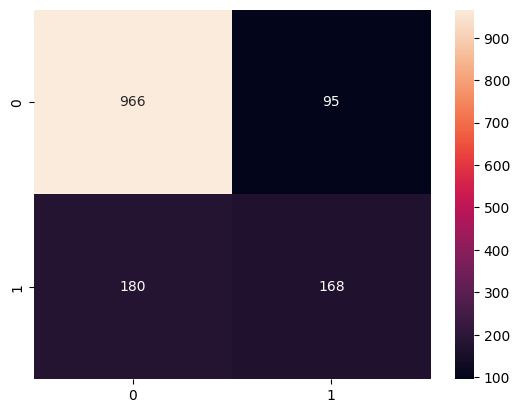

In [35]:
sns.heatmap(cm,annot=True,fmt="d")

## Precision for 0

In [36]:
# how this model can predict "0" correctly

round(966/(180+966),2)

0.84

## Precision for 1

In [ ]:
# how can this model predict  "1" correctly

round(229/(229+137),2)

0.63